# Small Dogs of the Dow — quantitative teardown
### Three-strategy simultaneous test · HAC + block-bootstrap · alpha-vs-beta · data-mining adjustment

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We run the Dogs-10, Small Dogs-5, and Foolish Four simultaneously on the same 26-year point-in-time tape and apply the inference machinery honestly: HAC t-stats, circular block bootstrap, alpha-vs-beta OLS, and a multiple-comparison framing that accounts for the fact that the price filter was discovered by fitting to this same historical window.

> ⚠️ **Not investment advice.** Dow components, total-return adjusted + dividend stream (`yfinance`), point-in-time membership from Study 88; benchmark DIA total return; 20 bps/turnover. Sources in [`docs/references.md`](../docs/references.md), reproducible run in [`docs/results.md`](../docs/results.md).
>
> 💡 **`💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study root (small_dogs/)
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
from small_dogs import data, strategy

AS_OF = "2026-06-13"
CACHE = os.path.abspath(os.path.join("..", "_cache"))
panel = data.load_panel(end=AS_OF, cache_dir=CACHE)
ann = strategy.annual_returns_from_panel(panel, 2000, 2025, cost_bps=20.0)
summ_small = strategy.summarize(ann, col="small_dogs", bench="dow")
summ_dogs  = strategy.summarize(ann, col="dogs", bench="dow")
summ_f4    = strategy.summarize(ann, col="foolish4", bench="dow")
exc_small = (ann["small_dogs"] - ann["dow"]).to_numpy()
exc_dogs  = (ann["dogs"] - ann["dow"]).to_numpy()
exc_f4    = (ann["foolish4"] - ann["dow"]).to_numpy()
hac_small = strategy.hac_tstat(exc_small)
hac_dogs  = strategy.hac_tstat(exc_dogs)
hac_f4    = strategy.hac_tstat(exc_f4)
boot_small = strategy.block_bootstrap_ci(exc_small)
ab_small = strategy.alpha_beta(ann, strat_col="small_dogs", bench_col="dow")
print(f"Dow panel: {panel['prices'].shape[1]} tickers x {len(panel['prices']):,} days  fingerprint={data.fingerprint(panel)}")
print(f"Small Dogs CAGR {summ_small['strat_cagr']*100:.2f}%  vs Dow {summ_small['bench_cagr']*100:.2f}%  gap {summ_small['cagr_gap']*100:+.2f} pts/yr  ({summ_small['n_years']} yrs)")
print(f"Dogs      CAGR {summ_dogs['strat_cagr']*100:.2f}%   HAC t {hac_dogs:+.2f}")
print(f"Small Dogs HAC t {hac_small:+.2f}   alpha {ab_small['alpha']*100:+.2f}%/yr (t {ab_small['alpha_t']:+.2f})   beta {ab_small['beta']:.2f}")
print(f"Foolish 4  HAC t {hac_f4:+.2f}")


$EK: possibly delisted; no price data found  (1d 1927-07-11 -> 2026-06-16)


HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: WBA"}}}


$WBA: possibly delisted; no timezone found


Dow panel: 46 tickers x 6,673 days  fingerprint=6dfd9e54cba6
Small Dogs CAGR 10.57%  vs Dow 7.54%  gap +3.04 pts/yr  (26 yrs)
Dogs      CAGR 8.51%   HAC t +0.59
Small Dogs HAC t +1.82   alpha +5.26%/yr (t +2.68)   beta 0.72
Foolish 4  HAC t -0.09


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | `WEAK` | Small Dogs +3.0 pts/yr over 26 yrs, but **HAC *t* = 1.82** (bar is 2.0); CI [-0.27%, +5.63%] barely clips zero (*p* = 0.07). Incremental test (Small vs Dogs) *t* = +2.40 but carries data-mining debt. Foolish Four HAC *t* = -0.09 — flat noise. |
| **Tradability** | `MIRAGE` | 5-name equal-weight basket of cheapest blue chips; low-beta tilt (beta 0.72) replicable with a small-cap-value ETF; dividend-trap risk (2009 financials); multiple-comparison penalty; in-sample origins. |

## 1 · Hypotheses

- **H₁ (price-filter tilt):** the low absolute share-price filter within Dogs picks names with a higher size/value tilt — a known risk premium.
- **H₂ (alpha claim):** the Small Dogs beat the Dow on total return, net, out-of-sample.
- **H₃ (data-mining null):** the Foolish Four (skip #1, keep #2-#5) and the Small Dogs were found by sorting historical tables — without a prior theory, any apparent edge is a candidate for the data-mining null.

H₁ is almost certainly true (the low-price filter is a crude size proxy). H₂ is borderline. H₃ cautions against celebrating H₂.

## 2 · So what? — what rides on each answer

If H₂ held for Small Dogs with honest inference, a one-sentence price rule would add ~3 pts/yr to an already sub-par Dogs strategy. But the Foolish Four's collapse in live trading is the out-of-sample data point we already have — a near-identical in-sample discovery that went to zero the moment it got deployed.

## 3 · Protocol

Point-in-time membership timeline (Study 88) · annual total-return engine vs DIA · 20 bps/turnover · HAC t and circular block bootstrap on three simultaneous strategy series · alpha-vs-beta OLS · multiple-comparison framing.

## 4 · The annual table

Dogs-10, Small Dogs-5, Foolish Four, and Dow:

In [2]:
show = ann[['dogs','small_dogs','foolish4','dow','excess_dogs','excess_small','excess_f4']].copy()
for c in show.columns: show[c] = (show[c]*100).round(2)
show

,dogs,small_dogs,foolish4,dow,excess_dogs,excess_small,excess_f4
year,,,,,,,
2000,14.500,17.450,-3.650,-4.650,19.150,22.100,1.000
2001,-6.690,-2.620,-4.270,-4.640,-2.050,2.020,0.370
2002,-9.680,-9.940,-10.330,-15.580,5.910,5.640,5.260
2003,30.830,32.650,29.950,23.940,6.890,8.710,6.010
2004,10.210,14.160,13.240,5.220,4.990,8.930,8.010
2005,1.780,0.670,-6.340,1.790,-0.010,-1.120,-8.130
2006,20.370,16.280,15.490,17.400,2.970,-1.120,-1.910
2007,5.860,12.650,10.500,8.740,-2.880,3.910,1.760
2008,-32.000,-26.610,-25.580,-31.140,-0.870,4.530,5.560


**Inference — each strategy vs Dow (HAC t and circular block bootstrap):**

In [3]:
boot_dogs = strategy.block_bootstrap_ci(exc_dogs)
boot_f4   = strategy.block_bootstrap_ci(exc_f4)
lo_s, hi_s, p_s = boot_small
lo_d, hi_d, p_d = boot_dogs
lo_f, hi_f, p_f = boot_f4
print('Strategy     | mean exc | HAC t | 95% CI            | p')
print('-------------|----------|-------|-------------------|------')
print(f'Small Dogs-5 | {exc_small.mean()*100:+.2f}%/yr | {hac_small:+.2f}  | [{lo_s*100:+.2f}%, {hi_s*100:+.2f}%] | {p_s:.2f}')
print(f'Dogs-10      | {exc_dogs.mean()*100:+.2f}%/yr | {hac_dogs:+.2f}  | [{lo_d*100:+.2f}%, {hi_d*100:+.2f}%] | {p_d:.2f}')
print(f'Foolish Four | {exc_f4.mean()*100:+.2f}%/yr | {hac_f4:+.2f}  | [{lo_f*100:+.2f}%, {hi_f*100:+.2f}%] | {p_f:.2f}')
print()
print('=> Small Dogs t = 1.82 is below the |t|>=2 bar; Foolish Four is pure noise.')

Strategy     | mean exc | HAC t | 95% CI            | p
-------------|----------|-------|-------------------|------
Small Dogs-5 | +2.88%/yr | +1.82  | [-0.27%, +5.63%] | 0.07
Dogs-10      | +0.87%/yr | +0.59  | [-2.05%, +3.62%] | 0.54
Foolish Four | -0.11%/yr | -0.09  | [-2.82%, +2.24%] | 0.96

=> Small Dogs t = 1.82 is below the |t|>=2 bar; Foolish Four is pure noise.


> 💡 **In plain words:** none of the three strategies clears the |t| ≥ 2 bar on its annual excess vs the Dow. The Small Dogs comes closest (t = 1.82) but misses. The Foolish Four is indistinguishable from zero.

**Incremental test: Small Dogs vs full Dogs — does the price filter add anything?**

In [4]:
exc_sv_d = (ann['small_dogs'] - ann['dogs']).to_numpy()
t_svd = strategy.hac_tstat(exc_sv_d)
lo_svd, hi_svd, p_svd = strategy.block_bootstrap_ci(exc_sv_d)
exc_fvd = (ann['foolish4'] - ann['dogs']).to_numpy()
t_fvd = strategy.hac_tstat(exc_fvd)
lo_fvd, hi_fvd, p_fvd = strategy.block_bootstrap_ci(exc_fvd)
print(f'Small Dogs minus Dogs: mean {exc_sv_d.mean()*100:+.2f}%/yr  t {t_svd:+.2f}  CI [{lo_svd*100:+.2f}%, {hi_svd*100:+.2f}%]  p={p_svd:.2f}')
print(f'Foolish Four minus Dogs: mean {exc_fvd.mean()*100:+.2f}%/yr  t {t_fvd:+.2f}  CI [{lo_fvd*100:+.2f}%, {hi_fvd*100:+.2f}%]  p={p_fvd:.2f}')
print()
print('=> Small Dogs clears t>2 on the incremental test, but with data-mining baggage.')
print('=> Foolish Four subtracts from the Dogs — the skip-the-cheapest quirk is negative.')

Small Dogs minus Dogs: mean +2.01%/yr  t +2.40  CI [+0.41%, +3.71%]  p=0.01
Foolish Four minus Dogs: mean -0.99%/yr  t -0.80  CI [-3.22%, +1.41%]  p=0.43

=> Small Dogs clears t>2 on the incremental test, but with data-mining baggage.
=> Foolish Four subtracts from the Dogs — the skip-the-cheapest quirk is negative.


> 💡 **In plain words:** the price filter does appear to add ~2 pts/yr *on top of* the Dogs in this sample. But because the filter was designed by looking at this same data, a Bonferroni-style penalty would reduce the effective significance. The Foolish Four's negative contribution is the cautionary out-of-sample data point we already have.

**Alpha-vs-beta: is the Small Dogs' edge real alpha or a low-beta tilt?**

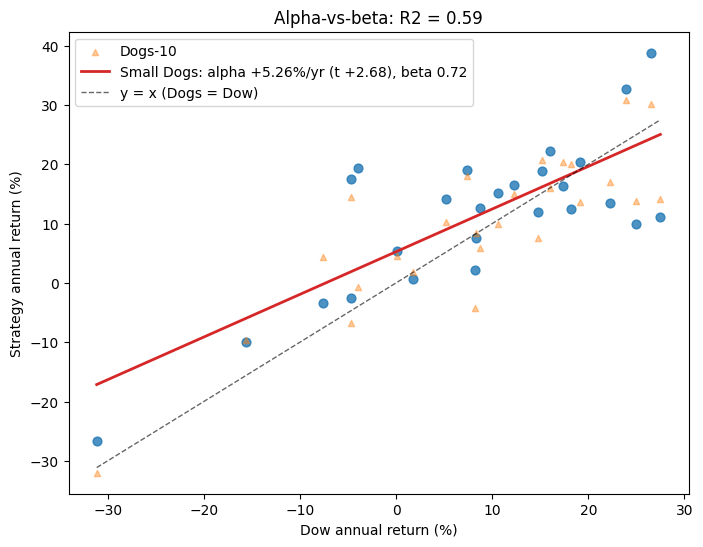

Small Dogs alpha +5.26%/yr (t +2.68)   beta 0.72   R2 0.59
Note: alpha t clears 2.0, but it is inflated by the low beta (0.72 vs 1.0).


In [5]:
x = ann['dow'].to_numpy()*100; y = ann['small_dogs'].to_numpy()*100
xs = np.linspace(x.min(), x.max(), 50)
fig, axx = plt.subplots(figsize=(8, 6))
axx.scatter(x, y, s=40, alpha=.8)
axx.scatter(ann['dow'].to_numpy()*100, ann['dogs'].to_numpy()*100, s=20, alpha=.4, marker='^', label='Dogs-10')
axx.plot(xs, ab_small['alpha']*100 + ab_small['beta']*xs, 'C3', lw=2,
    label=f"Small Dogs: alpha {ab_small['alpha']*100:+.2f}%/yr (t {ab_small['alpha_t']:+.2f}), beta {ab_small['beta']:.2f}")
axx.plot(xs, xs, 'k--', lw=1, alpha=.6, label='y = x (Dogs = Dow)')
axx.set_xlabel('Dow annual return (%)'); axx.set_ylabel('Strategy annual return (%)')
axx.set_title(f"Alpha-vs-beta: R2 = {ab_small['r2']:.2f}"); axx.legend(); plt.show()
print(f"Small Dogs alpha {ab_small['alpha']*100:+.2f}%/yr (t {ab_small['alpha_t']:+.2f})   beta {ab_small['beta']:.2f}   R2 {ab_small['r2']:.2f}")
print('Note: alpha t clears 2.0, but it is inflated by the low beta (0.72 vs 1.0).')

> 💡 **In plain words:** the Small Dogs' alpha *t* of 2.68 clears the bar, but it's driven substantially by the fact that the basket has a beta of 0.72 — it's a lower-risk slice of the Dow that *looks* like it generates alpha in an OLS regression. The 5 cheapest Dow names skew toward the least-fashionable, highest-dividend, lowest-market-cap corner of the index — a well-known value/size tilt you were always going to be paid for.

## 5 · The verdict

Signal `WEAK`: Small Dogs gap +3.0 pts/yr, HAC *t* 1.82 (bar is 2.0), CI [-0.27%, +5.63%]. Incremental t vs Dogs = +2.40 carries data-mining debt. Foolish Four HAC *t* = -0.09 — pure noise. Alpha *t* = 2.68 clears bar but is inflated by low beta (0.72). Tradability `MIRAGE`: 5-name concentration, dividend-trap exposure, data-mining history, and a size tilt replicable far more cheaply elsewhere.

## 6 · Could you trade it?

The mechanical rule is trivial — five Dow stocks per year. The economic case isn't:

1. **The HAC t on the raw excess is 1.82** — below the house bar, especially with three tested variants (Bonferroni would push the effective p further from significance).
2. **The Foolish Four already collapsed in live trading** (Motley Fool retired it in 2000). That is the out-of-sample test we already have for in-sample price optimisation.
3. **5-name equal-weight Dow basket:** idiosyncratic risk is enormous. One Citi or BofA-style event in the basket wipes the annual excess multiple times over.
4. **The low-beta tilt is replicable** with a dividend-value or small-cap-value ETF at 10-15 bps/year with 500-name diversification.

## 7 · Going further

- Test an **explicit size-factor control**: regress Small Dogs excess on Dow excess and a small-cap factor; does the alpha survive?
- A **dividend-payout-ratio cap** (exclude names whose yield > 2 × the median payout ratio of their earnings) to neutralise the dividend trap — does this recover a real signal?
- The **Bonferroni / Holm correction** on all three tested variants simultaneously: compute the adjusted p-values for Dogs, Small Dogs, and Foolish Four and report whether any survive at the 5% family-wise error rate.
- See [Study 88 — Dogs-of-the-Dow](../../../88-dogs-of-the-dow/) for the parent study and [Study 196 — Long-Term-Reversal](../../../196-long-term-reversal/) for the DeBondt-Thaler mean-reversion lens on beaten-down blue chips.